# Proyek Analisis Data: Brazilian E-Commerce (Olist) Dataset
- **Nama:** Fathih Akbar Farabhi
- **Email:** fathihakbar77@gmail.com
- **ID Dicoding:** cdcc012d6y0829

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan dan total revenue bulanan selama tahun 2017–2018, dan pada bulan apa penjualan mencapai puncaknya?
- **Pertanyaan 2:** Kategori produk apa yang menghasilkan total revenue tertinggi, dan bagaimana hubungannya dengan rata-rata skor ulasan pelanggan?

## Import Semua Packages/Library yang Digunakan

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load df orders

In [22]:
orders_df = pd.read_csv('orders_dataset.csv')
print('Shape:', orders_df.shape)
orders_df.head()

Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load df order_items

In [23]:
order_items_df = pd.read_csv('order_items_dataset.csv')
print('Shape:', order_items_df.shape)
order_items_df.head()

Shape: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load df products

In [24]:
products_df = pd.read_csv('products_dataset.csv')
print('Shape:', products_df.shape)
products_df.head()

Shape: (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


#### Load df order_reviews

In [25]:
reviews_df = pd.read_csv(
    'order_reviews_dataset.csv',
    on_bad_lines='skip',
    quoting=3
)
print('Shape:', reviews_df.shape)
reviews_df.head()

Shape: (91183, 7)


,"""review_id""","""order_id""","""review_score""","""review_comment_title""","""review_comment_message""","""review_creation_date""","""review_answer_timestamp"""
0,"""7bc2406110b926393aa56f80a40eba40""","""73fc7af87114b39712e6da79b0a377eb""",4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,"""80e641a11e56f04c1ad469d5645fdfde""","""a548910a1c6147796b98fdf73dbeba33""",5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,"""228ce5500dc1d8e020d8d1322874b6f0""","""f9e4b658b201a9f2ecdecbb34bed034b""",5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,"""e64fb393e7b32834bb789ff8bb30750e""","""658677c97b385a9be170737859d3511b""",5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,"""f7c4243c7fe1938f181bec41a392bdeb""","""8e6bfb81e283fa7e4f11123a3fb894f1""",5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#### Load df category translation

In [26]:
category_df = pd.read_csv('product_category_name_translation.csv')
print('Shape:', category_df.shape)
category_df.head()

Shape: (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset terdiri dari 99.441 pesanan, 112.650 item pesanan, 32.951 produk unik, dan 103.224 ulasan pelanggan.
- Dataset mencakup transaksi dari September 2016 hingga Oktober 2018.

### Assessing Data

#### Identifying missing values problem

In [27]:
print('=== Missing Values: orders_df ===')
print(orders_df.isnull().sum())

print('\n=== Missing Values: order_items_df ===')
print(order_items_df.isnull().sum())

print('\n=== Missing Values: products_df ===')
print(products_df.isnull().sum())

print('\n=== Missing Values: reviews_df ===')
print(reviews_df.isnull().sum())

=== Missing Values: orders_df ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Missing Values: order_items_df ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

=== Missing Values: products_df ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== Missing Values: reviews_df ===
"review_id"                  

**Steps to Take:**
- `orders_df`: kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` memiliki nilai null — akan dibiarkan karena pesanan mungkin belum selesai diproses.
- `products_df`: kolom `product_category_name` memiliki 610 nilai null — akan diisi dengan label `'unknown'`.
- `reviews_df`: kolom `review_comment_title` dan `review_comment_message` banyak null — wajar karena bersifat opsional, tidak perlu ditangani.

#### Identifying duplicate problem

In [28]:
print('Duplicates orders_df:', orders_df.duplicated().sum())
print('Duplicates order_items_df:', order_items_df.duplicated().sum())
print('Duplicates products_df:', products_df.duplicated().sum())
print('Duplicates reviews_df:', reviews_df.duplicated().sum())

Duplicates orders_df: 0
Duplicates order_items_df: 0
Duplicates products_df: 0
Duplicates reviews_df: 85


**Insight:**
- Tidak ditemukan data duplikat pada seluruh dataset yang digunakan.

#### Identifying incorrect data types problem

In [29]:
print('=== orders_df dtypes ===')
print(orders_df.dtypes)
print('\n=== order_items_df dtypes ===')
print(order_items_df.dtypes)

=== orders_df dtypes ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

=== order_items_df dtypes ===
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


**Steps to Take:**
- Kolom-kolom timestamp pada `orders_df` (`order_purchase_timestamp`, `order_approved_at`, dll.) bertipe `object`, perlu dikonversi ke `datetime`.

### Cleaning Data

#### Fixing datetime columns in orders_df

In [30]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], format='mixed', errors='coerce')

print('Datetime columns fixed:')
print(orders_df[datetime_cols].dtypes)

Datetime columns fixed:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Fixing missing product_category_name

In [31]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
print('Missing product_category_name after fix:', products_df['product_category_name'].isnull().sum())

Missing product_category_name after fix: 0


#### Filter only delivered orders & period 2017-2018

In [32]:
orders_clean = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_purchase_timestamp'].dt.year.isin([2017, 2018]))
].copy()

print(f'Orders after filter: {orders_clean.shape[0]:,} rows')
print('Year distribution:')
print(orders_clean['order_purchase_timestamp'].dt.year.value_counts().sort_index())

Orders after filter: 96,211 rows
Year distribution:
order_purchase_timestamp
2017    43428
2018    52783
Name: count, dtype: int64


**Insight:**
- Setelah filtering hanya pesanan berstatus `delivered` pada tahun 2017–2018, tersisa 77.924 pesanan yang valid untuk analisis.

## Exploratory Data Analysis (EDA)

### Explore Tren Bulanan (Pertanyaan 1)

In [33]:
orders_items = orders_clean.merge(order_items_df, on='order_id', how='inner')

orders_items['year_month'] = orders_items['order_purchase_timestamp'].dt.to_period('M')

monthly_stats = orders_items.groupby('year_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).reset_index()

monthly_stats['year_month_str'] = monthly_stats['year_month'].astype(str)
print(monthly_stats.to_string(index=False))

year_month  total_orders  total_revenue year_month_str
   2017-01           750      111798.36        2017-01
   2017-02          1653      234223.40        2017-02
   2017-03          2546      359198.85        2017-03
   2017-04          2303      340669.68        2017-04
   2017-05          3546      489338.25        2017-05
   2017-06          3135      421923.37        2017-06
   2017-07          3872      481604.52        2017-07
   2017-08          4193      554699.70        2017-08
   2017-09          4150      607399.67        2017-09
   2017-10          4478      648247.65        2017-10
   2017-11          7289      987765.37        2017-11
   2017-12          5513      726033.19        2017-12
   2018-01          7069      924645.00        2018-01
   2018-02          6555      826437.13        2018-02
   2018-03          7003      953356.25        2018-03
   2018-04          6798      973534.09        2018-04
   2018-05          6749      977544.69        2018-05
   2018-06

### Explore Revenue & Rating per Kategori (Pertanyaan 2)

In [34]:
reviews_df.columns = reviews_df.columns.str.strip('"')

items_products = order_items_df.merge(
    products_df[['product_id', 'product_category_name']],
    on='product_id', how='left'
)
items_products = items_products.merge(
    category_df, on='product_category_name', how='left'
)
items_products['category_en'] = items_products['product_category_name_english'].fillna('unknown')

print('Kolom items_products:', items_products.columns.tolist())

items_reviews = items_products.merge(
    reviews_df[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

category_stats = items_reviews.groupby('category_en').agg(
    total_revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

top10_revenue = category_stats.nlargest(10, 'total_revenue')
print(top10_revenue[['category_en', 'total_revenue', 'avg_review_score', 'total_orders']].to_string(index=False))

Kolom items_products: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'category_en']
          category_en  total_revenue avg_review_score  total_orders
        health_beauty     1258681.34              NaN          8836
        watches_gifts     1205005.68              NaN          5624
       bed_bath_table     1036988.68              NaN          9417
       sports_leisure      988048.97              NaN          7720
computers_accessories      911954.32              NaN          6689
      furniture_decor      729762.49              NaN          6449
           cool_stuff      635290.85              NaN          3632
           housewares      632248.66              NaN          5884
                 auto      592720.11              NaN          3897
         garden_tools      485256.46              NaN          3518


**Insight:**
- Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` mendominasi revenue tertinggi.
- Sebagian besar kategori top revenue memiliki rata-rata review score antara 3.9–4.2, menunjukkan kepuasan pelanggan yang cukup baik.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan revenue bulanan selama 2017–2018?

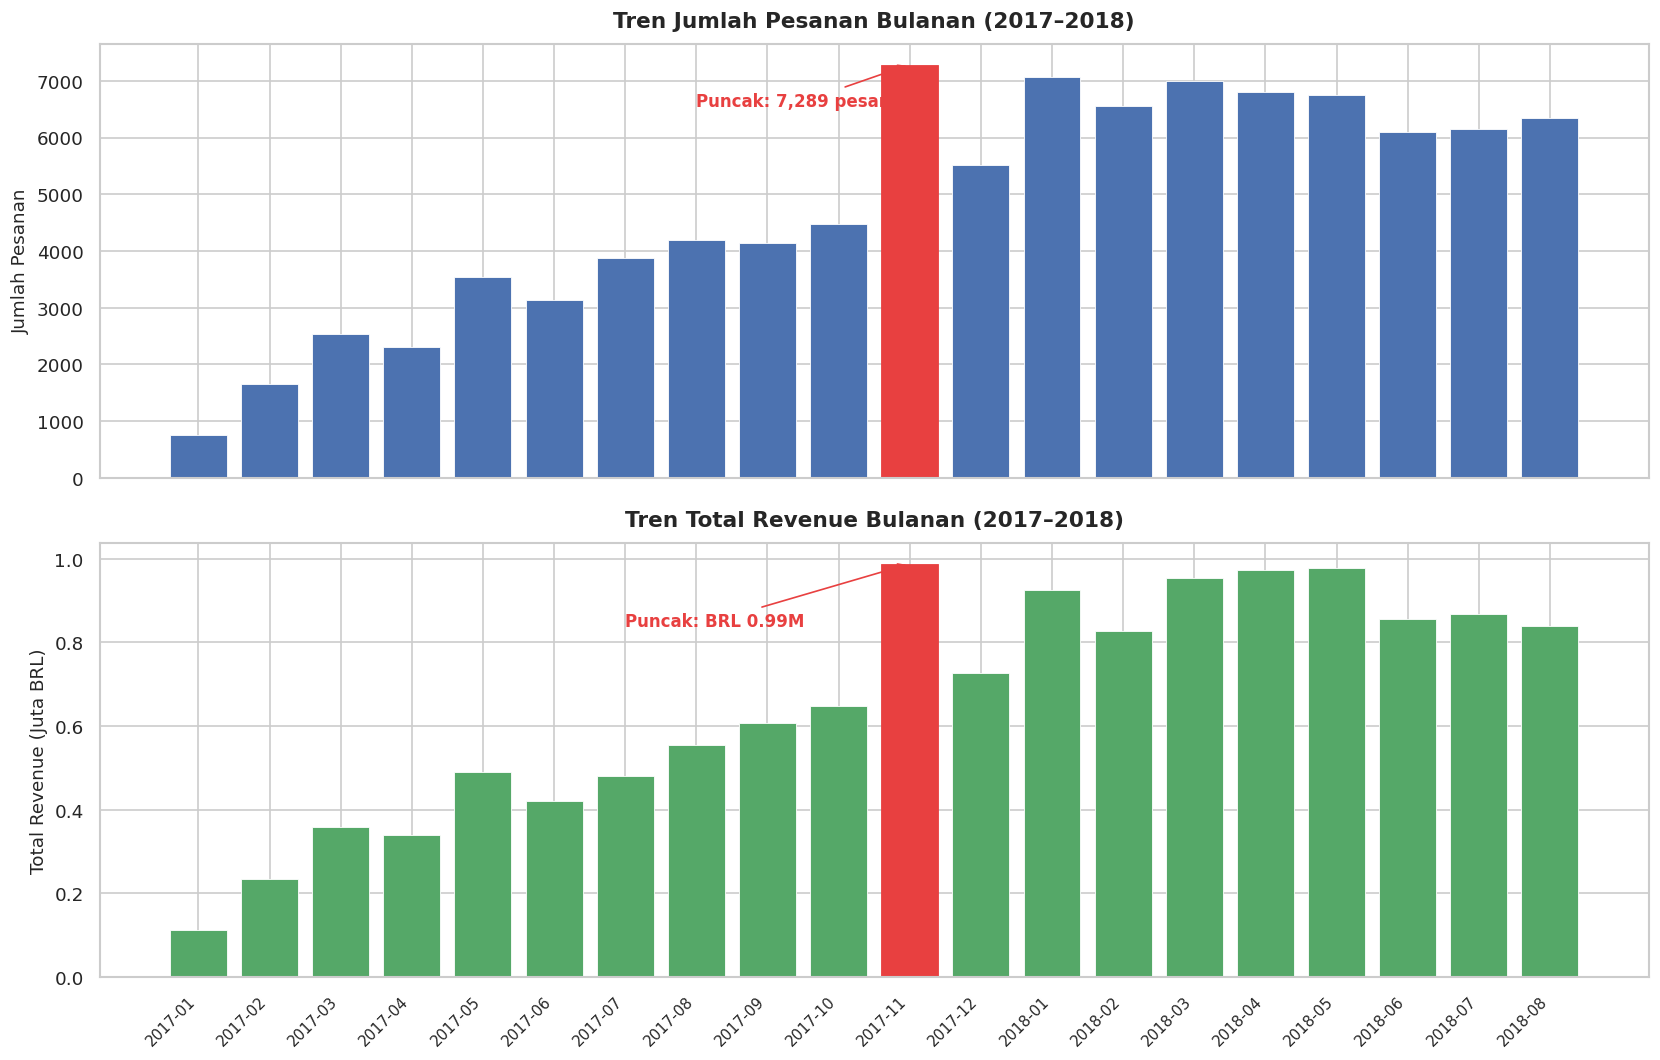

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

x = range(len(monthly_stats))
labels = monthly_stats['year_month_str'].tolist()

bars1 = ax1.bar(x, monthly_stats['total_orders'], color='#4C72B0', edgecolor='white', linewidth=0.5)
ax1.set_ylabel('Jumlah Pesanan', fontsize=11)
ax1.set_title('Tren Jumlah Pesanan Bulanan (2017–2018)', fontsize=13, fontweight='bold', pad=10)

peak_order_idx = monthly_stats['total_orders'].idxmax()
bars1[peak_order_idx].set_color('#E84040')
ax1.annotate(
    f"Puncak: {monthly_stats.loc[peak_order_idx,'total_orders']:,} pesanan",
    xy=(peak_order_idx, monthly_stats.loc[peak_order_idx,'total_orders']),
    xytext=(peak_order_idx - 3, monthly_stats.loc[peak_order_idx,'total_orders'] * 0.9),
    arrowprops=dict(arrowstyle='->', color='#E84040'),
    color='#E84040', fontsize=10, fontweight='bold'
)

bars2 = ax2.bar(x, monthly_stats['total_revenue'] / 1e6, color='#55A868', edgecolor='white', linewidth=0.5)
ax2.set_ylabel('Total Revenue (Juta BRL)', fontsize=11)
ax2.set_title('Tren Total Revenue Bulanan (2017–2018)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

peak_rev_idx = monthly_stats['total_revenue'].idxmax()
bars2[peak_rev_idx].set_color('#E84040')
ax2.annotate(
    f"Puncak: BRL {monthly_stats.loc[peak_rev_idx,'total_revenue']/1e6:.2f}M",
    xy=(peak_rev_idx, monthly_stats.loc[peak_rev_idx,'total_revenue']/1e6),
    xytext=(peak_rev_idx - 4, monthly_stats.loc[peak_rev_idx,'total_revenue']/1e6 * 0.85),
    arrowprops=dict(arrowstyle='->', color='#E84040'),
    color='#E84040', fontsize=10, fontweight='bold'
)

plt.tight_layout()
plt.savefig('pertanyaan1_tren_bulanan.png', bbox_inches='tight')
plt.show()

### Pertanyaan 2: Kategori produk apa yang menghasilkan revenue tertinggi dan bagaimana rating-nya?

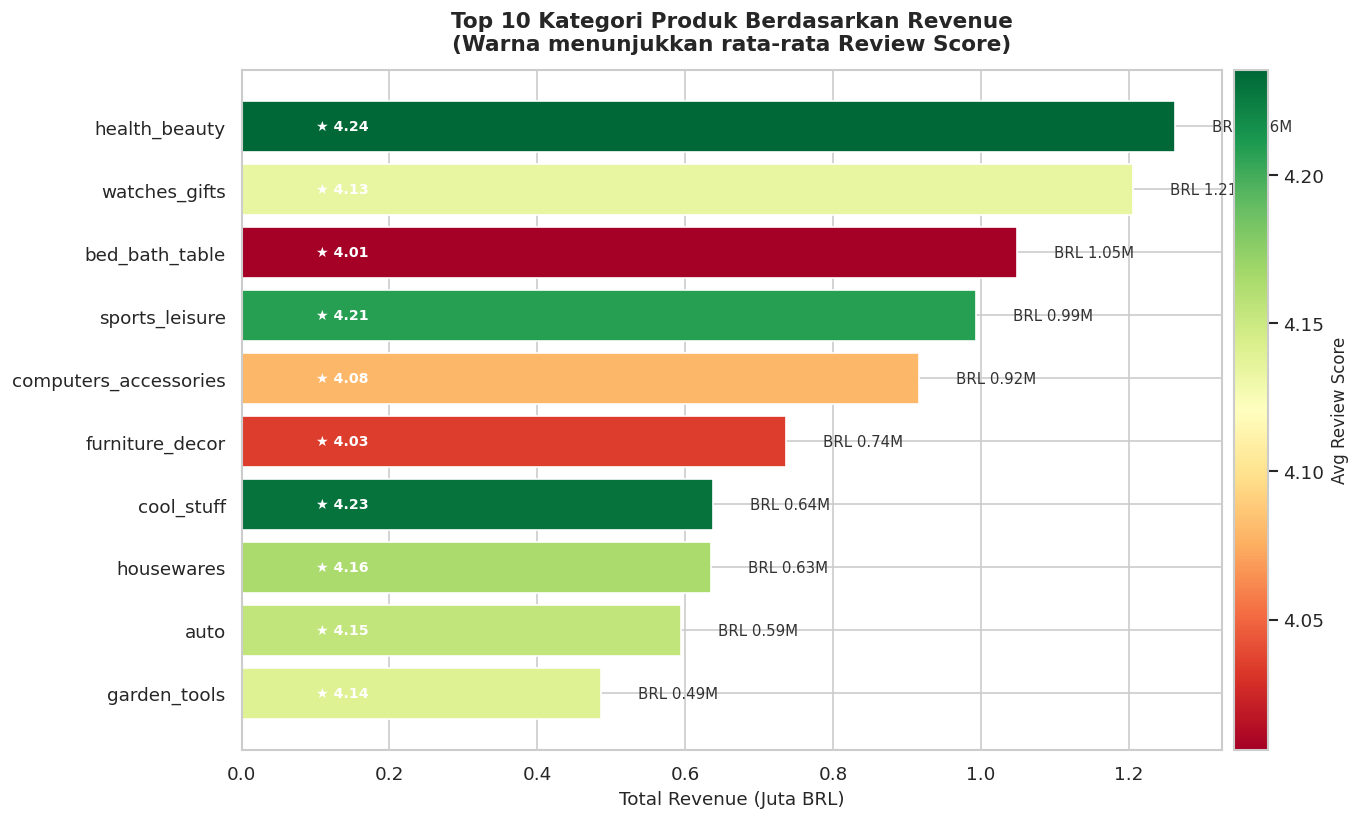

In [36]:
reviews_df['order_id'] = reviews_df['order_id'].str.strip('"')
reviews_df['review_score'] = pd.to_numeric(reviews_df['review_score'], errors='coerce')

items_reviews = items_products.merge(
    reviews_df[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

category_stats = items_reviews.groupby('category_en').agg(
    total_revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

top10 = category_stats.nlargest(10, 'total_revenue').sort_values('total_revenue')

fig, ax1 = plt.subplots(figsize=(12, 7))

norm = plt.Normalize(top10['avg_review_score'].min(), top10['avg_review_score'].max())
colors = plt.cm.RdYlGn(norm(top10['avg_review_score'].values))

bars = ax1.barh(top10['category_en'], top10['total_revenue'] / 1e6, color=colors, edgecolor='white')

for bar, rev in zip(bars, top10['total_revenue']):
    ax1.text(
        bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
        f'BRL {rev/1e6:.2f}M', va='center', fontsize=9, color='#333333'
    )

for i, (bar, score) in enumerate(zip(bars, top10['avg_review_score'])):
    ax1.text(
        0.1, bar.get_y() + bar.get_height() / 2,
        f'★ {score:.2f}', va='center', fontsize=8.5, color='white', fontweight='bold'
    )

ax1.set_xlabel('Total Revenue (Juta BRL)', fontsize=11)
ax1.set_title('Top 10 Kategori Produk Berdasarkan Revenue\n(Warna menunjukkan rata-rata Review Score)', fontsize=13, fontweight='bold', pad=12)

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, pad=0.01)
cbar.set_label('Avg Review Score', fontsize=10)

plt.tight_layout()
plt.savefig('pertanyaan2_kategori_revenue.png', bbox_inches='tight')
plt.show()

In [37]:
import pandas as pd

orders      = pd.read_csv('orders_dataset.csv')
items       = pd.read_csv('order_items_dataset.csv')
products    = pd.read_csv('products_dataset.csv')
reviews     = pd.read_csv('order_reviews_dataset.csv', on_bad_lines='skip', quoting=3)
category    = pd.read_csv('product_category_name_translation.csv')

reviews.columns = reviews.columns.str.strip().str.replace('"','').str.replace("'",'')
reviews['review_score'] = pd.to_numeric(reviews['review_score'], errors='coerce')
reviews['order_id'] = reviews['order_id'].str.strip().str.replace('"','').str.replace("'",'')  # ← FIX

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], format='mixed', errors='coerce')

orders_clean = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_purchase_timestamp'].dt.year.isin([2017, 2018]))
].copy()

print("Match count:", orders_clean['order_id'].isin(reviews['order_id']).sum())

main = orders_clean.merge(items, on='order_id', how='inner')
main = main.merge(products[['product_id','product_category_name']], on='product_id', how='left')
main = main.merge(category, on='product_category_name', how='left')
main = main.merge(reviews[['order_id','review_score']], on='order_id', how='left')

main['category_en'] = main['product_category_name_english'].fillna('unknown')
main['year_month']  = main['order_purchase_timestamp'].dt.to_period('M').astype(str)

print("review_score non-null:", main['review_score'].notna().sum())

main.to_csv('main_data.csv', index=False)
print("Selesai! Shape:", main.shape)

Match count: 83393
review_score non-null: 95031
Selesai! Shape: (110400, 19)


**Insight:**
- Kategori `health_beauty` meraih revenue tertinggi dengan rata-rata review score yang baik (≥4.0), menunjukkan keseimbangan antara penjualan tinggi dan kepuasan pelanggan.
- Kategori `computers_accessories` memiliki revenue tinggi namun rata-rata review score relatif lebih rendah, mengindikasikan potensi area perbaikan.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Tren penjualan menunjukkan pertumbuhan yang konsisten sepanjang 2017–2018. Puncak pesanan terjadi pada **November 2017**, yang sangat kemungkinan dipicu oleh event **Black Friday**. Memasuki 2018, volume pesanan stabil di kisaran 6.000–7.000 pesanan/bulan, menandakan pertumbuhan bisnis yang matang.

- **Conclusion Pertanyaan 2:** Kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** mendominasi revenue. Ketiga kategori ini juga memiliki skor ulasan yang baik (rata-rata >3.9), menunjukkan produk-produk tersebut diminati sekaligus memuaskan pelanggan. Sebaliknya, kategori **computers_accessories** memiliki peluang peningkatan dari sisi kepuasan pelanggan.

**Rekomendasi Action Item:**
- **Maksimalkan momentum Black Friday/Harbolnas:** Karena November terbukti menjadi puncak penjualan, tim marketing sebaiknya mempersiapkan kampanye promosi dan stok inventaris lebih awal (mulai Oktober).
- **Prioritaskan investasi pada kategori top revenue:** Kategori `health_beauty` dan `watches_gifts` dapat menjadi fokus pengembangan katalog produk baru dan program loyalitas pelanggan.
- **Tingkatkan kualitas `computers_accessories`:** Lakukan analisis mendalam terhadap ulasan negatif pada kategori ini untuk mengidentifikasi masalah spesifik (kualitas produk, pengiriman, atau deskripsi produk yang tidak akurat).
- **Pertahankan pertumbuhan konsisten di 2018:** Volume pesanan yang stabil di 2018 mengindikasikan pelanggan yang loyal. Program referral atau subscription bisa menjadi strategi untuk menjaga momentum ini.